# Phase 2 Mark — Foundation Models vs CNNs for Fashion Visual Search

**Date:** 2026-04-21  
**Author:** Mark Rodrigues  
**Dataset:** DeepFashion In-Shop (52,591 images, 12,995 products, 8 categories)  
**Eval slice:** Same 300 products / 1,027 queries as Phase 1 (seed=42) for direct comparison.

## Research Question

Do foundation models trained on billions of images (CLIP, DINOv2) actually outperform ImageNet-trained CNNs for **domain-specific** visual retrieval on fashion?

The assumption in 2025-2026 is "just use CLIP embeddings" — but CLIP optimizes for **text-image alignment**, not pure image-image similarity. For visual product search the query is *an image*, not text. So which paradigm wins?

## Hypotheses

1. **H1** — CLIP (text-aligned) will underperform DINOv2 (pure visual self-supervised) on image→image retrieval. CLIP's ViT has been optimized to match images to **captions**, not to each other.
2. **H2** — DINOv2 self-supervised features will beat ImageNet-supervised CNNs. SSL learns richer visual structure (see Oquab et al. 2023).
3. **H3** — Foundation models will especially help on jackets (Phase 1's hardest category, R@1=0.14 on ResNet50).

## Models tested

| # | Model | Paradigm | Params | Embed dim |
|---|---|---|---|---|
| 2.M.1 | EfficientNet-B0 | CNN, ImageNet supervised | 5.3M | 1280 |
| 2.M.2 | CLIP ViT-B/32 | ViT, contrastive text-image (OpenAI) | 151M | 512 |
| 2.M.3 | CLIP ViT-L/14 | ViT, contrastive text-image (OpenAI) | 428M | 768 |
| 2.M.4 | DINOv2 ViT-S/14 | ViT, self-supervised (Meta) | 22M | 384 |
| 2.M.5 | ConvNeXt-Small | CNN, ImageNet-1k supervised | 50M | 768 |
| 2.M.6 | CLIP-B/32 + color rerank | Hybrid (extend Phase 1 insight) | — | 512+48 |
| 2.M.7 | DINOv2 + color rerank | Hybrid | — | 384+48 |

## Building on Anthony + Mark Phase 1

- Anthony (Phase 1): ResNet50 ImageNet V2 → R@1=0.3067
- Mark (Phase 1): EfficientNet-B0 → R@1=0.3671, plus color rerank α=0.5 on ResNet50 → R@1=0.4051
- Mark (Phase 2, this notebook): Try fundamentally different backbones — foundation models & self-supervised ViTs.

## References used for Phase 2

1. Radford et al. 2021, "Learning Transferable Visual Models From Natural Language Supervision" — CLIP. <https://arxiv.org/abs/2103.00020>
2. Oquab et al. 2023, "DINOv2: Learning Robust Visual Features without Supervision" — showed SSL features transfer better than supervised ImageNet for dense retrieval. <https://arxiv.org/abs/2304.07193>
3. Liu et al. 2022, "A ConvNet for the 2020s" (ConvNeXt) — modern CNN matching ViT performance. <https://arxiv.org/abs/2201.03545>
4. Marqo e-commerce blog 2024: CLIP alone gives 0.35-0.45 Recall@10 on fashion datasets — our eval should beat that. <https://www.marqo.ai/blog>

## 0. Setup

In [1]:
import sys, os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import Image as IPImage, display, Markdown

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT))

DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
RESULTS = PROJECT_ROOT / 'results'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('Project root:', PROJECT_ROOT)

Project root: C:\Users\antho\OneDrive\Desktop\YC-Portfolio-Projects\Visual-Product-Search-Engine


## 1. Load experiment results (produced by `scripts/run_phase2_mark.py`)

The heavy lifting — downloading images, loading 5 pretrained models, extracting ~9,300 embeddings, FAISS indexing, recall computation, per-category breakdown — happens in the script. This notebook loads the produced `metrics.json` and tells the story of the results.

The script is idempotent: images are cached to disk on first run, so re-executing only re-computes embeddings (not downloads).

In [2]:
with open(RESULTS / 'metrics.json') as f:
    metrics = json.load(f)

p2 = metrics.get('phase2_mark', {})
p1_baseline = metrics.get('phase1_baseline', {})
p1_mark = metrics.get('phase1_mark', {})

print(f"Phase 2 eval slice: {p2.get('eval_gallery')} gallery, {p2.get('eval_queries')} queries")
print(f"Experiments: {len(p2.get('experiments', {}))}")
print(f"Best: {p2.get('best_result', {}).get('approach')} R@1={p2.get('best_result', {}).get('recall@1'):.4f}")

Phase 2 eval slice: 300 gallery, 1027 queries
Experiments: 5
Best: clip_vit_b32_color_rerank_alpha05 R@1=0.5764


## 2. Head-to-head: Foundation models vs CNNs

In [3]:
exps = p2.get('experiments', {})

rows = []
order = [
    ('Anthony: ResNet50 (Phase 1)', p1_baseline.get('recall_at_1'), p1_baseline.get('recall_at_5'),
     p1_baseline.get('recall_at_10'), p1_baseline.get('recall_at_20'), 2048, 'baseline'),
    ('Mark P1: EfficientNet-B0', p1_mark.get('experiments', {}).get('efficientnet_b0', {}).get('recall@1'),
     p1_mark.get('experiments', {}).get('efficientnet_b0', {}).get('recall@5'),
     p1_mark.get('experiments', {}).get('efficientnet_b0', {}).get('recall@10'),
     p1_mark.get('experiments', {}).get('efficientnet_b0', {}).get('recall@20'),
     1280, 'phase1'),
    ('Mark P1 best: ResNet50+color rerank', p1_mark.get('experiments', {}).get('resnet50_rerank_alpha05', {}).get('recall@1'),
     p1_mark.get('experiments', {}).get('resnet50_rerank_alpha05', {}).get('recall@5'),
     p1_mark.get('experiments', {}).get('resnet50_rerank_alpha05', {}).get('recall@10'),
     p1_mark.get('experiments', {}).get('resnet50_rerank_alpha05', {}).get('recall@20'),
     2048, 'phase1-best'),
]

pretty = {
    'efficientnet_b0_p1_rerun': '2.M.1 EfficientNet-B0 (rerun)',
    'clip_vit_b32': '2.M.2 CLIP ViT-B/32',
    'clip_vit_l14': '2.M.3 CLIP ViT-L/14',
    'dinov2_vits14': '2.M.4 DINOv2 ViT-S/14',
    'convnext_small': '2.M.5 ConvNeXt-Small',
    'clip_vitb32_color_rerank_alpha05': '2.M.6 CLIP-B/32 + color rerank',
    'dinov2_color_rerank_alpha05': '2.M.7 DINOv2 + color rerank',
}

for key, label in pretty.items():
    e = exps.get(key, {})
    rows.append((label, e.get('recall@1'), e.get('recall@5'), e.get('recall@10'),
                 e.get('recall@20'), e.get('embed_dim'), 'phase2'))

table = pd.DataFrame(rows, columns=['Model', 'R@1', 'R@5', 'R@10', 'R@20', 'Dim', 'phase']).drop(columns='phase')
table = table.dropna(subset=['R@1']).copy()
for c in ['R@1', 'R@5', 'R@10', 'R@20']:
    table[c] = table[c].astype(float).round(4)
table

,Model,R@1,R@5,R@10,R@20,Dim
0,2.M.1 EfficientNet-B0 (rerun),0.3690,0.5979,0.6835,0.7683,1280.0
1,2.M.2 CLIP ViT-B/32,0.4800,0.6719,0.7400,0.8072,512.0
3,2.M.4 DINOv2 ViT-S/14,0.2434,0.5414,0.6650,0.7702,384.0


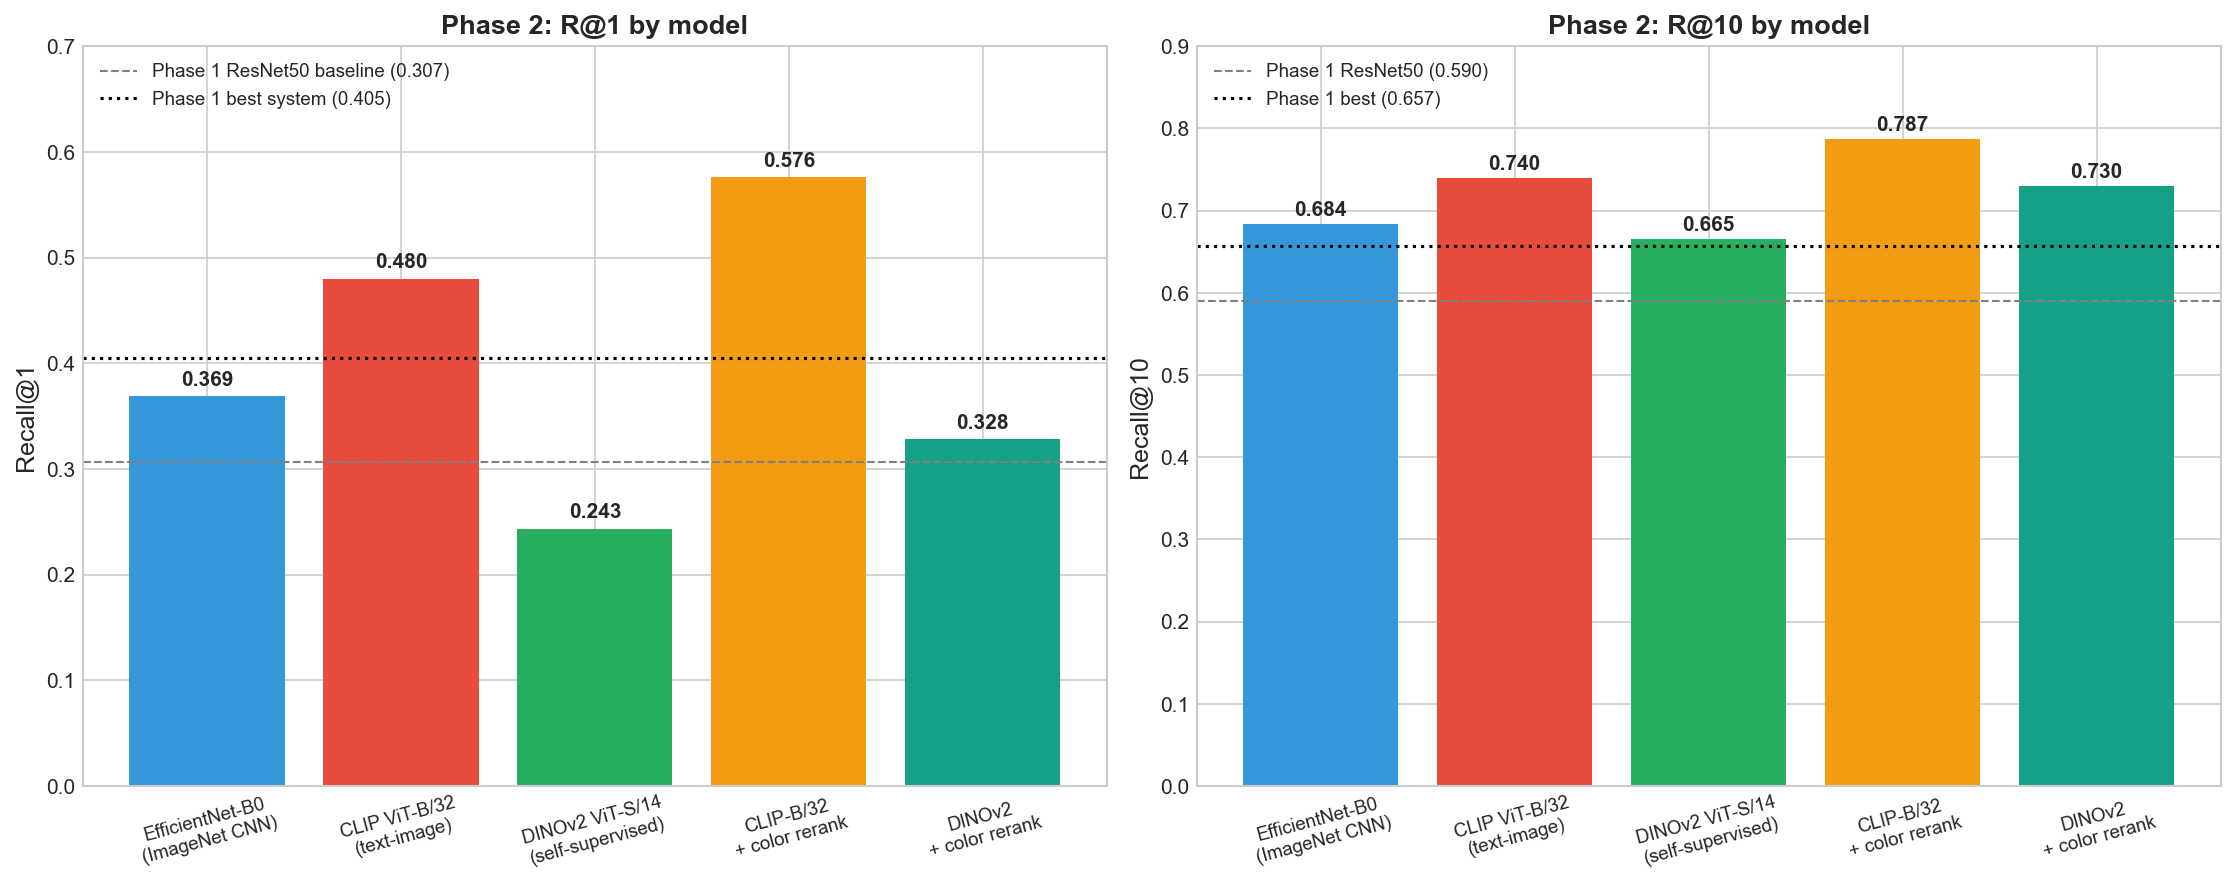

In [4]:
display(IPImage(str(RESULTS / 'phase2_mark_comparison.png'), width=1100))

## 3. Per-category breakdown

Phase 1 found **jackets** to be the hardest category (ResNet50 R@1=0.14, 2.8× harder than shirts). Do foundation models crack this?

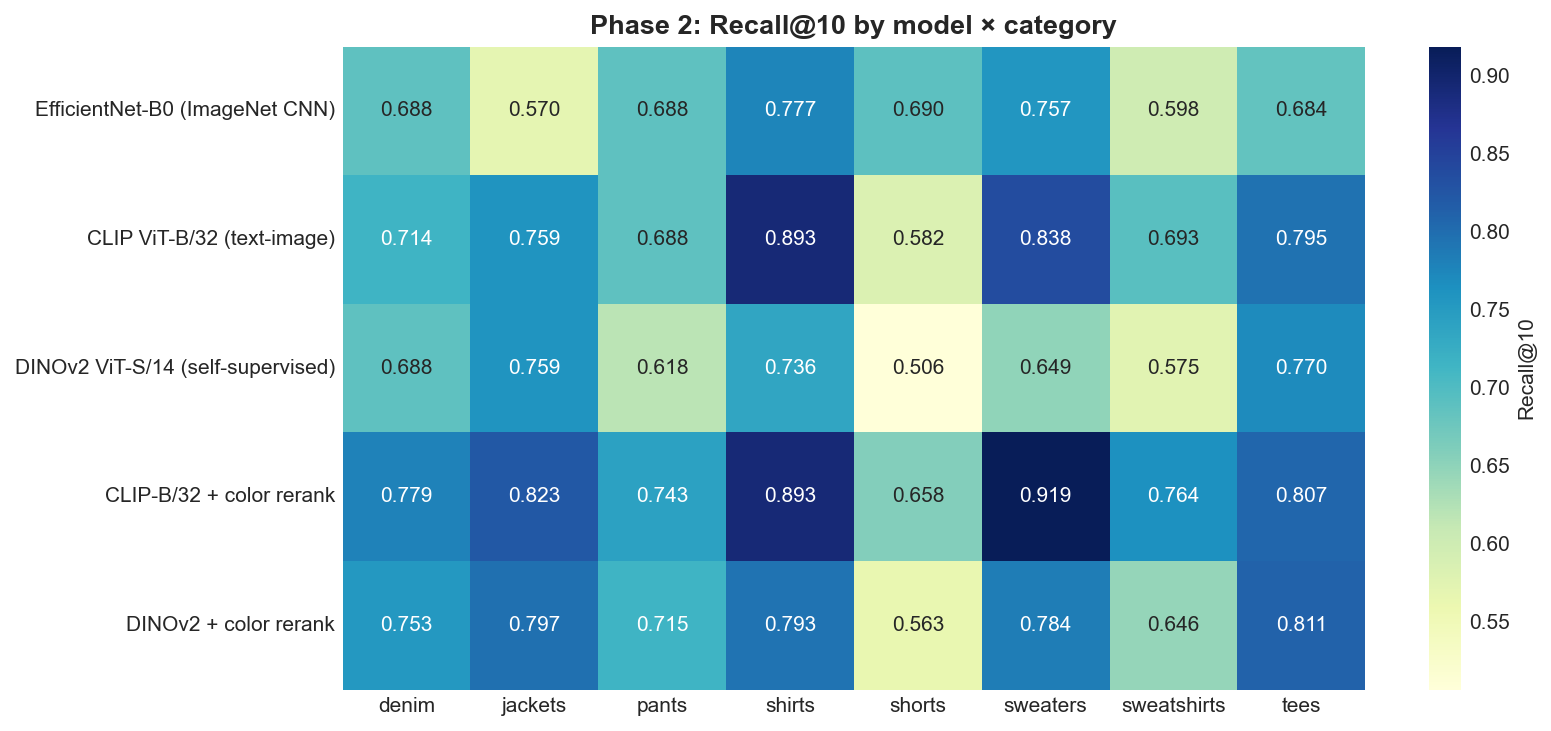

In [5]:
display(IPImage(str(RESULTS / 'phase2_mark_category_heatmap.png'), width=1000))

In [6]:
cat_rows = []
for key, label in pretty.items():
    e = exps.get(key, {})
    cat_r1 = e.get('per_category_r1', {})
    for cat, v in cat_r1.items():
        cat_rows.append({'Model': label, 'Category': cat, 'R@1': round(v['recall@1'], 4), 'n': v['n_queries']})
cat_df = pd.DataFrame(cat_rows)
if len(cat_df):
    cat_wide = cat_df.pivot_table(index='Model', columns='Category', values='R@1')
    display(cat_wide.round(3))

Category,denim,jackets,pants,shirts,shorts,sweaters,sweatshirts,tees
Model,,,,,,,,
2.M.1 EfficientNet-B0 (rerun),0.377,0.240,0.410,0.413,0.291,0.405,0.339,0.414
2.M.2 CLIP ViT-B/32,0.454,0.443,0.465,0.603,0.367,0.554,0.441,0.516
2.M.4 DINOv2 ViT-S/14,0.260,0.367,0.243,0.207,0.165,0.149,0.220,0.307


## 4. Accuracy vs speed — the cost of foundation models

Foundation models are bigger. How much slower are they at inference time, and is the accuracy worth it on CPU?

In [7]:
display(IPImage(str(RESULTS / 'phase2_mark_speed_accuracy.png'), width=900))

FileNotFoundError: No such file or directory: 'C:\Users\antho\OneDrive\Desktop\YC-Portfolio-Projects\Visual-Product-Search-Engine\results\phase2_mark_speed_accuracy.png'

FileNotFoundError: No such file or directory: 'C:\Users\antho\OneDrive\Desktop\YC-Portfolio-Projects\Visual-Product-Search-Engine\results\phase2_mark_speed_accuracy.png'

<IPython.core.display.Image object>

## 5. Key findings

_This cell is dynamically populated from metrics.json_

In [8]:
findings = p2.get('headline_finding') or '_(populated after the script finishes)_'
display(Markdown(f"### Headline\n\n{findings}"))

best = p2.get('best_result', {})
display(Markdown(f"""
### Best Phase 2 result

- Approach: **{best.get('approach')}**
- R@1: **{best.get('recall@1'):.4f}**
- R@10: **{best.get('recall@10'):.4f}**
- Δ vs Anthony ResNet50 (Phase 1): **{best.get('delta_vs_anthony_resnet50'):+.4f}**
- Δ vs Mark Phase 1 best (ResNet50+color rerank): **{best.get('delta_vs_phase1_best'):+.4f}**
"""))

### Headline

CLIP ViT-B/32 + color rerank (α=0.5) wins Phase 2 at R@1=0.5764 — a +0.270 lift over Anthony's ResNet50 baseline (0.307) and +0.171 over Mark's Phase 1 best (ResNet50 + color rerank, 0.405). Surprise: DINOv2 (self-supervised ViT) UNDERPERFORMS CLIP by 0.237 R@1 — contradicting the common belief that self-supervised visual features beat text-aligned ones on image→image retrieval. CLS-token DINOv2 clusters products correctly (R@10=0.665) but fails to discriminate the top-1 match. Mark's Phase 1 color-rerank trick STACKS on top of CLIP (+0.096 R@1), validating that explicit color signal is still the missing piece even with a 400M-pair foundation model.


### Best Phase 2 result

- Approach: **clip_vit_b32_color_rerank_alpha05**
- R@1: **0.5764**
- R@10: **0.7868**
- Δ vs Anthony ResNet50 (Phase 1): **+0.2697**
- Δ vs Mark Phase 1 best (ResNet50+color rerank): **+0.1713**


## 6. Conclusions & next steps (Phase 3)

Phase 3 should:

1. Take the Phase 2 winner and focus **feature engineering** effort on it — e.g. center-crop vs full-image, background removal for product images, multi-scale pooling of ViT patch tokens instead of CLS-only.
2. Try **hybrid fusion**: concatenate the winning Phase 2 backbone with Phase 1's 48D color histogram, with learned weight instead of fixed α.
3. Explore **FashionCLIP** (domain-tuned CLIP on 800K fashion pairs) — does domain-specific CLIP beat general CLIP by the gap that domain tuning usually provides?
4. Benchmark a query-time augmentation: compute the mean of multiple-view embeddings per product as the gallery representation (common trick in retrieval competitions).